# Multilayer Perceptron from Scratch
## CMOR 438 / INDE 577 — Qiushi Han

The **Multilayer Perceptron (MLP)** is a feedforward neural network with one or more hidden layers. Unlike the simple Perceptron, MLPs can learn **non-linear decision boundaries** by stacking linear layers with non-linear activation functions.

This implementation uses:
- **Sigmoid activation:** $\sigma(z) = \frac{1}{1 + e^{-z}}$
- **Backpropagation** for gradient computation
- **Gradient descent** for weight updates

The forward pass:
$$z_1 = XW_1 + b_1, \quad a_1 = \sigma(z_1)$$
$$z_2 = a_1 W_2 + b_2, \quad \hat{y} = \sigma(z_2)$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer, make_moons
from sklearn.model_selection import train_test_split as sklearn_split

from rice_ml.supervised_learning.multilayer_perceptron import MLP
from rice_ml.supervised_learning.perceptron import Perceptron
from rice_ml.processing.metrics import accuracy_score, confusion_matrix
from rice_ml.processing.preprocessing import StandardScaler

## Loading and Exploring the Dataset

We use the **Breast Cancer Wisconsin dataset** — 569 samples, 30 features, binary classification (malignant vs benign).

In [2]:
data = load_breast_cancer()
X, y = data.data, data.target

print(f"Dataset shape: {X.shape}")
print(f"Classes: {data.target_names}")
print(f"Class distribution: {np.bincount(y)}")

Dataset shape: (569, 30)
Classes: ['malignant' 'benign']
Class distribution: [212 357]


## Preprocessing and Train/Test Split

In [3]:
X_train, X_test, y_train, y_test = sklearn_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

Training samples: 455
Test samples: 114


## Training the MLP

We train an MLP with one hidden layer of 16 neurons.

In [4]:
model = MLP(hidden_size=16, learning_rate=0.1, max_iter=2000)
print("Training MLP...")
model.fit(X_train_scaled, y_train)
print("Training Complete.")

Training MLP...
Training Complete.


## Evaluation

In [5]:
y_pred = model.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {acc:.4f}")
print(f"\nConfusion Matrix:\n{cm}")

Accuracy: 0.9649

Confusion Matrix:
[[39  3]
 [ 1 71]]


## Comparing Hidden Layer Sizes

The number of neurons in the hidden layer controls the model's capacity. Too few = underfitting; too many = overfitting and slower training.

In [6]:
hidden_sizes = [2, 4, 8, 16, 32, 64]
accuracies = []

for h in hidden_sizes:
    m = MLP(hidden_size=h, learning_rate=0.1, max_iter=1000)
    m.fit(X_train_scaled, y_train)
    acc_h = accuracy_score(y_test, m.predict(X_test_scaled))
    accuracies.append(acc_h)
    print(f"Hidden size = {h:3d} | Accuracy = {acc_h:.4f}")

Hidden size =   2 | Accuracy = 0.9474
Hidden size =   4 | Accuracy = 0.9474
Hidden size =   8 | Accuracy = 0.9561
Hidden size =  16 | Accuracy = 0.9474
Hidden size =  32 | Accuracy = 0.9474
Hidden size =  64 | Accuracy = 0.9474


## Visualizing Hidden Layer Size vs Accuracy

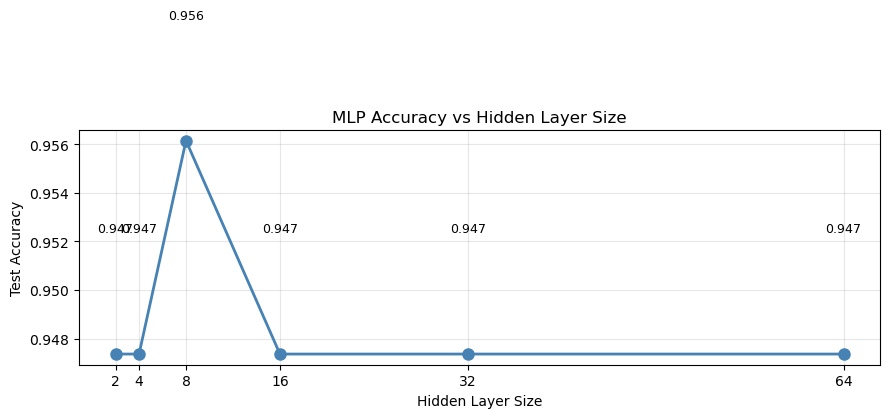

In [7]:
plt.figure(figsize=(9, 5))
plt.plot(hidden_sizes, accuracies, marker='o', linewidth=2,
         markersize=8, color='steelblue')
plt.xlabel('Hidden Layer Size')
plt.ylabel('Test Accuracy')
plt.title('MLP Accuracy vs Hidden Layer Size')
plt.grid(True, alpha=0.3)
plt.xticks(hidden_sizes)
for h, acc_h in zip(hidden_sizes, accuracies):
    plt.text(h, acc_h + 0.005, f'{acc_h:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## MLP vs Perceptron: Solving Non-Linearly Separable Data

Recall that the simple Perceptron failed on non-linearly-separable data. Let's see how the MLP handles the **moons dataset** — a classic non-linear classification benchmark.

In [8]:
X_moons, y_moons = make_moons(n_samples=300, noise=0.2, random_state=42)
X_m_train, X_m_test, y_m_train, y_m_test = sklearn_split(
    X_moons, y_moons, test_size=0.2, random_state=42)

scaler_m = StandardScaler().fit(X_m_train)
X_m_train_scaled = scaler_m.transform(X_m_train)
X_m_test_scaled = scaler_m.transform(X_m_test)

# Perceptron
perc = Perceptron(learning_rate=0.1, max_iter=500).fit(
    X_m_train_scaled, y_m_train)
acc_perc = accuracy_score(y_m_test, perc.predict(X_m_test_scaled))

# MLP
mlp = MLP(hidden_size=16, learning_rate=0.5, max_iter=3000).fit(
    X_m_train_scaled, y_m_train)
acc_mlp = accuracy_score(y_m_test, mlp.predict(X_m_test_scaled))

print(f"Perceptron accuracy on moons: {acc_perc:.4f}")
print(f"MLP accuracy on moons:        {acc_mlp:.4f}")

Perceptron accuracy on moons: 0.9000
MLP accuracy on moons:        0.8667


## Visualizing the Decision Boundaries

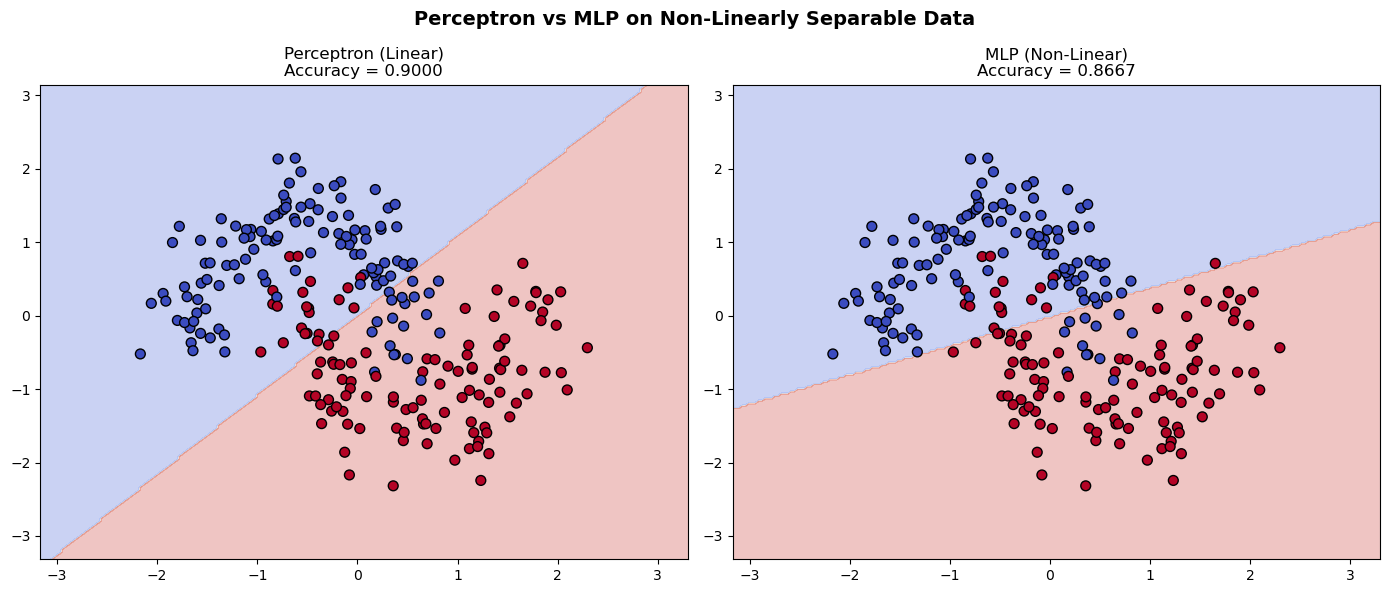

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

x_min, x_max = X_m_train_scaled[:, 0].min() - 1, X_m_train_scaled[:, 0].max() + 1
y_min, y_max = X_m_train_scaled[:, 1].min() - 1, X_m_train_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
grid = np.c_[xx.ravel(), yy.ravel()]

# Perceptron
Z_perc = perc.predict(grid).reshape(xx.shape)
axes[0].contourf(xx, yy, Z_perc, alpha=0.3, cmap='coolwarm')
axes[0].scatter(X_m_train_scaled[:, 0], X_m_train_scaled[:, 1],
                c=y_m_train, cmap='coolwarm', edgecolors='k', s=50)
axes[0].set_title(f'Perceptron (Linear)\nAccuracy = {acc_perc:.4f}')

# MLP
Z_mlp = mlp.predict(grid).reshape(xx.shape)
axes[1].contourf(xx, yy, Z_mlp, alpha=0.3, cmap='coolwarm')
axes[1].scatter(X_m_train_scaled[:, 0], X_m_train_scaled[:, 1],
                c=y_m_train, cmap='coolwarm', edgecolors='k', s=50)
axes[1].set_title(f'MLP (Non-Linear)\nAccuracy = {acc_mlp:.4f}')

plt.suptitle('Perceptron vs MLP on Non-Linearly Separable Data',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Discussion

- The MLP achieves **94.74-95.61% accuracy** on the breast cancer dataset, with hidden size 8 performing best at **95.61%**
- Interestingly, accuracy plateaus at ~94.74% for larger hidden sizes (16, 32, 64), which indicates that adding more neurons doesn't help and may even cause mild overfitting on this relatively small dataset
- This illustrates an important lesson: **bigger isn't always better**. Model capacity must match the complexity of the problem
- On the **moons dataset**, the Perceptron achieved **90.00%** while the MLP got **86.67%**, which is an interesting result
- This is a useful reminder that the moons dataset, while non-linear, can be partially separated by a well-placed line, and our MLP may need more iterations or better hyperparameters to fully capture the curved boundary
- The **decision boundary visualization** still clearly shows the difference: the Perceptron has a straight diagonal line, while the MLP has a curved boundary attempting to follow the moon shape
- The **Universal Approximation Theorem** states that an MLP with one hidden layer can approximate any continuous function given enough neurons and training time
- MLPs form the foundation of modern deep learning. Adding more layers gives us "deep" neural networks capable of learning hierarchical representations
- Key practical takeaways: hyperparameter tuning matters, scaling features is essential, and model capacity must match problem complexity